<a href="https://www.kaggle.com/code/omborse771924/comprehensive-car-market-analysis-eda?scriptVersionId=329545754" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lalit7881/comprehensive-car-market-analysis/v1-legacy-carapi-datafeed-sample.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lalit7881/comprehensive-car-market-analysis/v1-legacy-carapi-datafeed-sample.csv')

In [3]:
df.head()

,Make Id,Make Name,Model Id,Model Name,Trim Id,Trim Year,Trim Name,Trim Description,Trim Msrp,Trim Invoice,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
0,1,Acura,97,ILX,6292,2020,Base,4dr Sedan (2.4L 4cyl 8AM),25900,24617.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Acura,97,ILX,6295,2020,Premium and A-SPEC Packages,Premium and A-SPEC Packages 4dr Sedan (2.4L 4c...,29750,28264.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,Acura,97,ILX,6293,2020,Premium Package,Premium Package 4dr Sedan (2.4L 4cyl 8AM),27750,26370.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Acura,97,ILX,6296,2020,Technology and A-SPEC Packages,Technology and A-SPEC Packages 4dr Sedan (2.4L...,31650,30064.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Acura,97,ILX,6294,2020,Technology Package,Technology Package 4dr Sedan (2.4L 4cyl 8AM),29650,28169.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,Make Id,Make Name,Model Id,Model Name,Trim Id,Trim Year,Trim Name,Trim Description,Trim Msrp,Trim Invoice,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
17702,23,Volvo,589,XC70,23951,2015,3.2,3.2 4dr Wagon AWD (3.2L 6cyl 6A),36900,34686.0,...,25.0,333.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17703,23,Volvo,589,XC70,23950,2015,T5 Drive-E,T5 Drive-E 4dr Wagon (2.0L 4cyl Turbo 8A),36050,33887.0,...,31.0,444.0,574.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17704,23,Volvo,589,XC70,23949,2015,T5 Drive-E,T5 Drive-E 4dr Wagon (2.0L 4cyl Turbo 8A),35400,33276.0,...,31.0,444.0,574.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17705,23,Volvo,589,XC70,23954,2015,T6,T6 4dr Wagon AWD (3.0L 6cyl Turbo 6A),42050,39527.0,...,24.0,315.0,444.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17706,23,Volvo,589,XC70,23953,2015,T6,T6 4dr Wagon AWD (3.0L 6cyl Turbo 6A),41800,39292.0,...,24.0,315.0,444.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.describe()

,Make Id,Model Id,Trim Id,Trim Year,Trim Msrp,Trim Invoice,Engine Id,Engine Size,Engine Horsepower Hp,Engine Horsepower Rpm,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
count,17707.000000,17707.000000,17707.000000,17707.000000,1.770700e+04,17704.000000,17673.000000,17452.000000,17531.000000,17147.000000,...,14565.000000,17449.000000,17449.000000,462.000000,389.000000,389.000000,325.000000,299.000000,316.000000,161.000000
mean,20.042413,275.892133,15329.854916,2017.514655,4.854835e+04,39881.853479,15159.662197,3.481423,291.791113,5771.823001,...,27.946447,305.924867,413.428678,89.807359,96.192802,87.591260,106.766154,40.301003,5.139241,48.639752
std,12.748010,209.868165,6538.017344,1.694286,4.408983e+04,25761.988991,5306.128616,1.541130,109.890596,713.986235,...,6.673848,156.765174,208.121077,25.288781,29.979226,21.410929,113.190790,13.686925,3.551192,29.401861
min,1.000000,2.000000,6292.000000,2015.000000,0.000000e+00,0.000000,6292.000000,0.600000,66.000000,2800.000000,...,11.000000,0.000000,0.000000,39.000000,34.000000,37.000000,9.000000,24.000000,1.300000,1.000000
25%,8.000000,167.000000,10718.500000,2016.000000,3.048000e+04,27235.750000,10710.000000,2.000000,200.000000,5500.000000,...,23.000000,296.000000,406.000000,68.000000,68.000000,70.000000,19.000000,30.000000,2.700000,25.000000
50%,19.000000,267.000000,15145.000000,2018.000000,3.933500e+04,35931.500000,15128.000000,3.500000,285.000000,5750.000000,...,27.000000,348.000000,475.000000,97.000000,101.000000,93.000000,32.000000,33.000000,3.000000,38.000000
75%,29.000000,379.000000,19572.500000,2019.000000,5.104500e+04,46011.000000,19547.000000,4.400000,360.000000,6300.000000,...,32.000000,391.000000,537.000000,110.000000,124.000000,103.000000,215.000000,49.000000,8.125000,75.000000
max,56.000000,5024.000000,101978.000000,2020.000000,1.990064e+06,836100.000000,78461.000000,8.400000,1001.000000,9000.000000,...,354.000000,790.000000,900.000000,141.000000,150.000000,132.000000,402.000000,80.000000,15.300000,103.000000


In [6]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17702    False
17703    False
17704    False
17705    False
17706    False
Length: 17707, dtype: bool

In [7]:
df.isnull()

,Make Id,Make Name,Model Id,Model Name,Trim Id,Trim Year,Trim Name,Trim Description,Trim Msrp,Trim Invoice,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17702,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
17703,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
17704,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
17705,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Make Id                                            0
Make Name                                          0
Model Id                                           0
Model Name                                         0
Trim Id                                            0
Trim Year                                          0
Trim Name                                          0
Trim Description                                   0
Trim Msrp                                          0
Trim Invoice                                       3
Trim Created                                       0
Trim Modified                                      0
Engine Id                                         34
Engine Type                                       34
Engine Fuel Type                                  34
Engine Cylinders                                 255
Engine Size                                      255
Engine Horsepower Hp                             176
Engine Horsepower Rpm                         

In [10]:
# ============================================================
# SEPARATE NUMERIC AND CATEGORICAL
# ============================================================


numeric_cols = df.select_dtypes(
    include=["int64","float64"]
).columns



categorical_cols = df.select_dtypes(
    include=["object"]
).columns







# ============================================================
# HANDLE NUMERIC NULL VALUES
# MEDIAN METHOD
# ============================================================


for col in numeric_cols:


    df[col] = df[col].fillna(

        df[col].median()

    )








# ============================================================
# HANDLE CATEGORICAL NULL VALUES
# MODE METHOD
# ============================================================


for col in categorical_cols:


    df[col] = df[col].fillna(

        df[col].mode()[0]

    )










# ============================================================
# CHECK AFTER
# ============================================================


print("\nAfter Handling Missing Values")


print(

    df.isnull().sum()

)





print(

    "\nTotal Missing Values:",

    df.isnull().sum().sum()

)


After Handling Missing Values
Make Id                                        0
Make Name                                      0
Model Id                                       0
Model Name                                     0
Trim Id                                        0
Trim Year                                      0
Trim Name                                      0
Trim Description                               0
Trim Msrp                                      0
Trim Invoice                                   0
Trim Created                                   0
Trim Modified                                  0
Engine Id                                      0
Engine Type                                    0
Engine Fuel Type                               0
Engine Cylinders                               0
Engine Size                                    0
Engine Horsepower Hp                           0
Engine Horsepower Rpm                          0
Engine Torque Ft Lbs                  

In [11]:
df.columns

Index(['Make Id', 'Make Name', 'Model Id', 'Model Name', 'Trim Id',
       'Trim Year', 'Trim Name', 'Trim Description', 'Trim Msrp',
       'Trim Invoice', 'Trim Created', 'Trim Modified', 'Engine Id',
       'Engine Type', 'Engine Fuel Type', 'Engine Cylinders', 'Engine Size',
       'Engine Horsepower Hp', 'Engine Horsepower Rpm', 'Engine Torque Ft Lbs',
       'Engine Torque Rpm', 'Engine Valves', 'Engine Valve Timing',
       'Engine Cam Type', 'Engine Drive Type', 'Engine Transmission',
       'Body Id', 'Body Type', 'Body Doors', 'Body Seats', 'Body Length',
       'Body Width', 'Body Height', 'Body Wheel Base', 'Body Front Track',
       'Body Rear Track', 'Body Ground Clearance', 'Body Cargo Capacity',
       'Body Max Cargo Capacity', 'Body Curb Weight', 'Body Gross Weight',
       'Body Max Payload', 'Body Max Towing Capacity', 'Mileage Id',
       'Mileage Fuel Tank Capacity', 'Mileage Combined Mpg',
       'Mileage Epa City Mpg', 'Mileage Epa Highway Mpg', 'Mileage Range C

## EDA

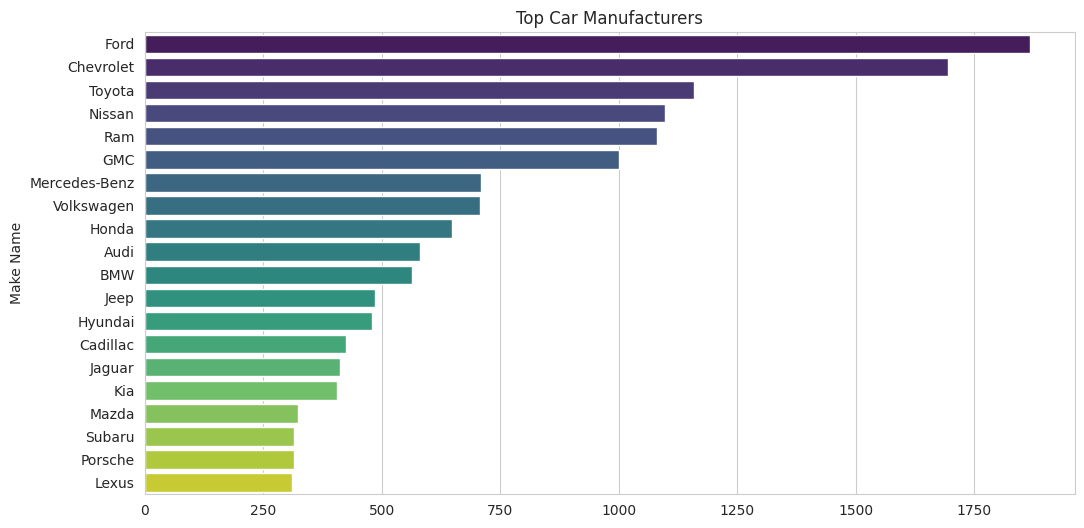

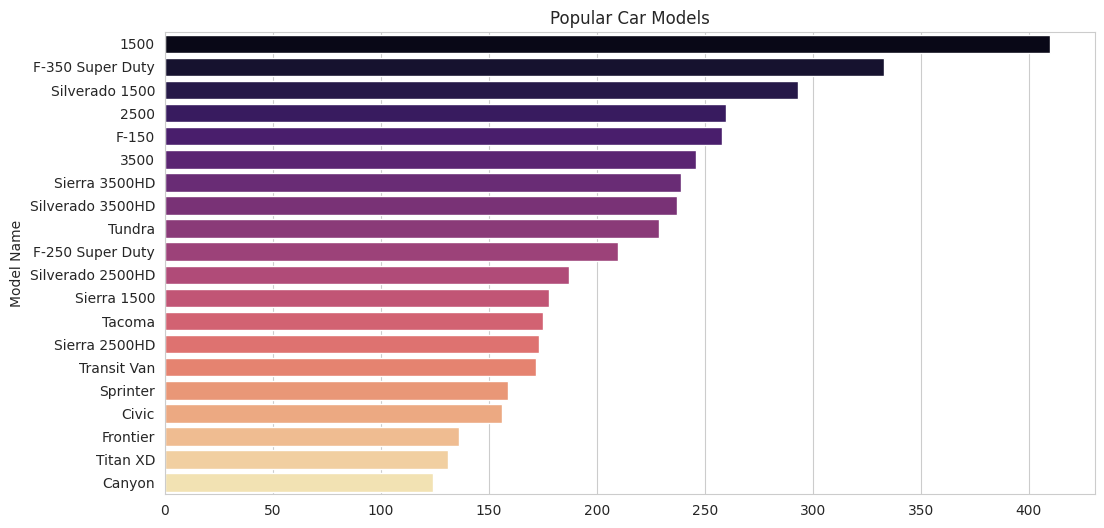

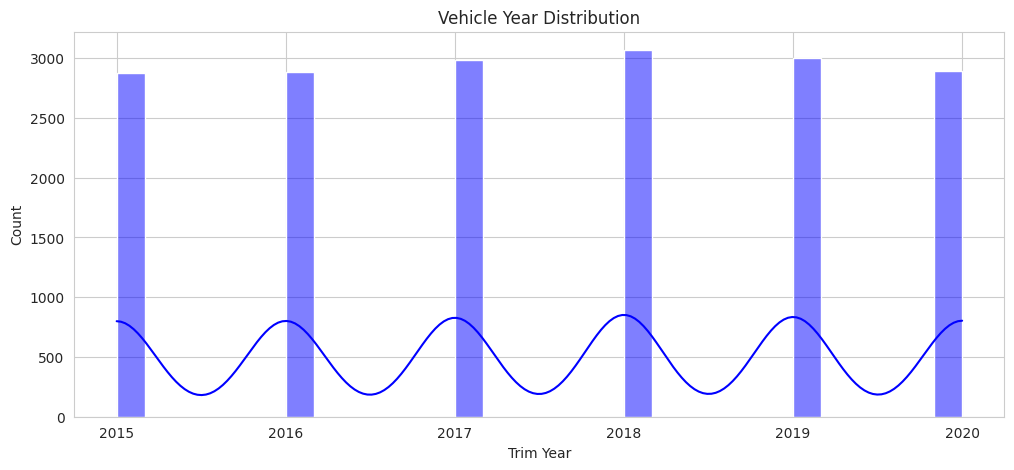

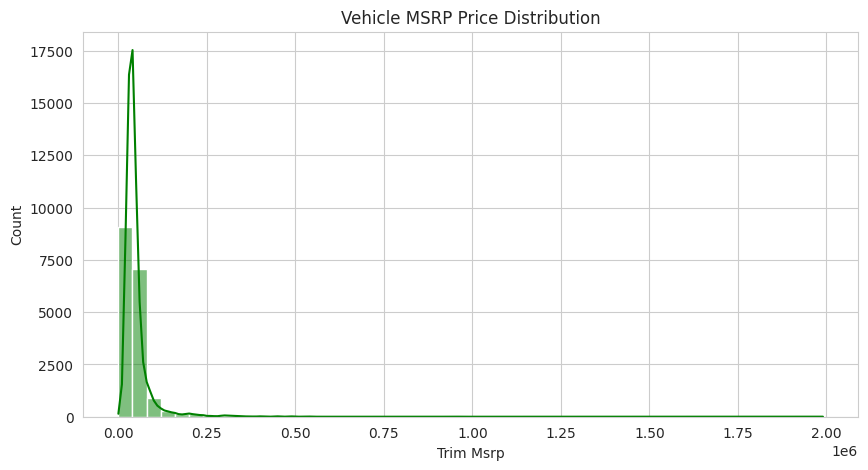

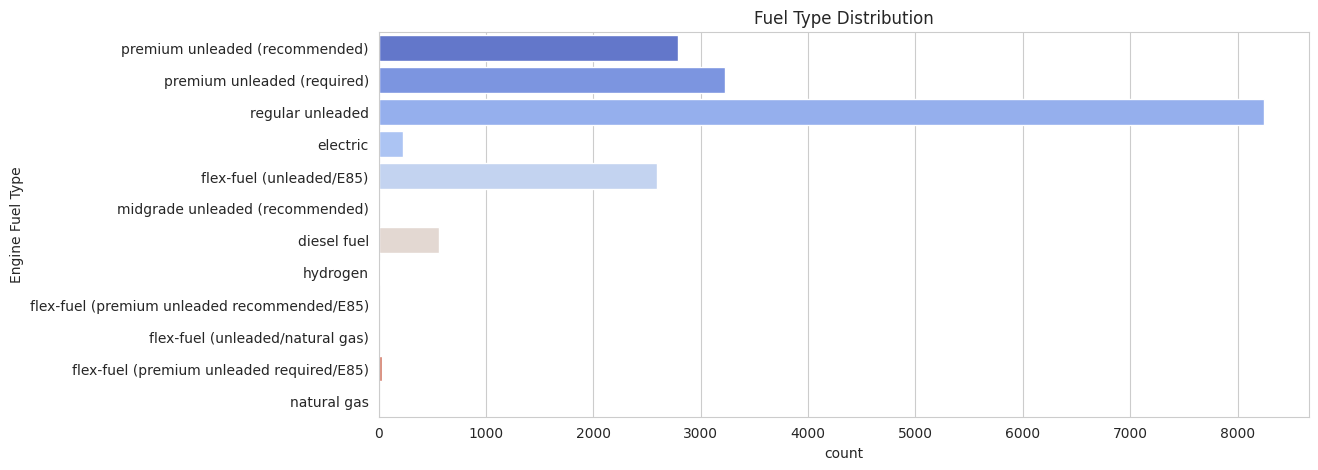

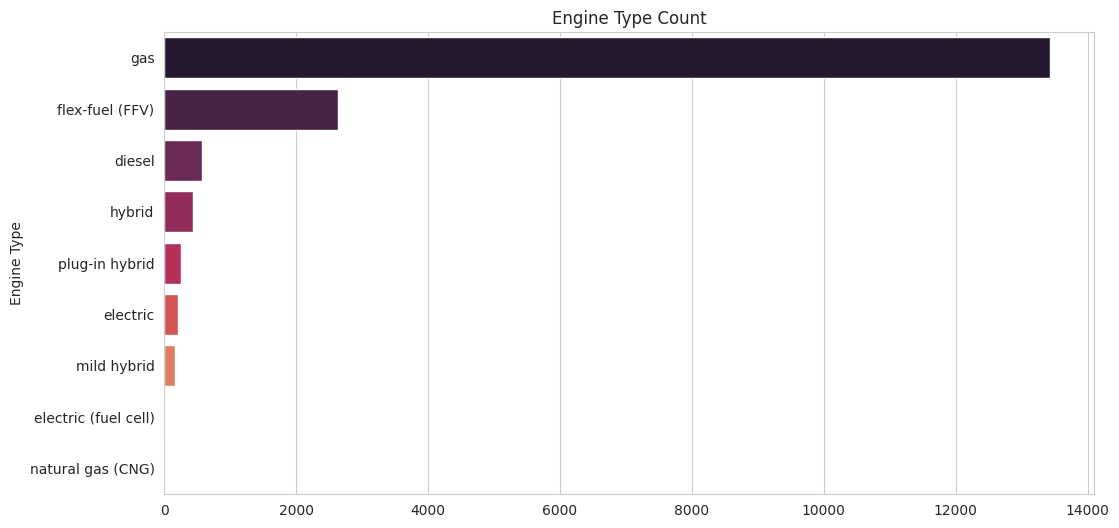

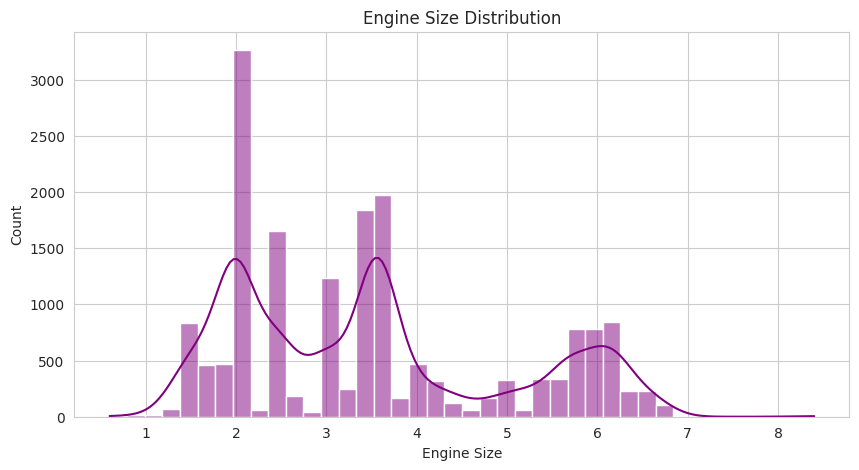

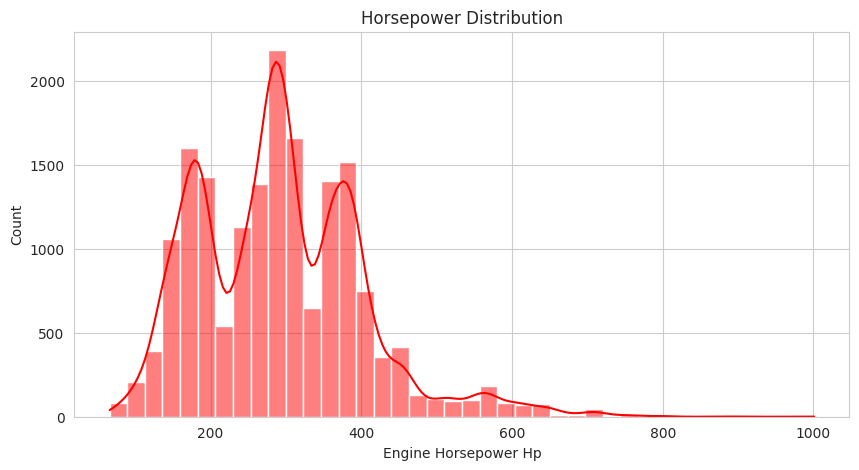

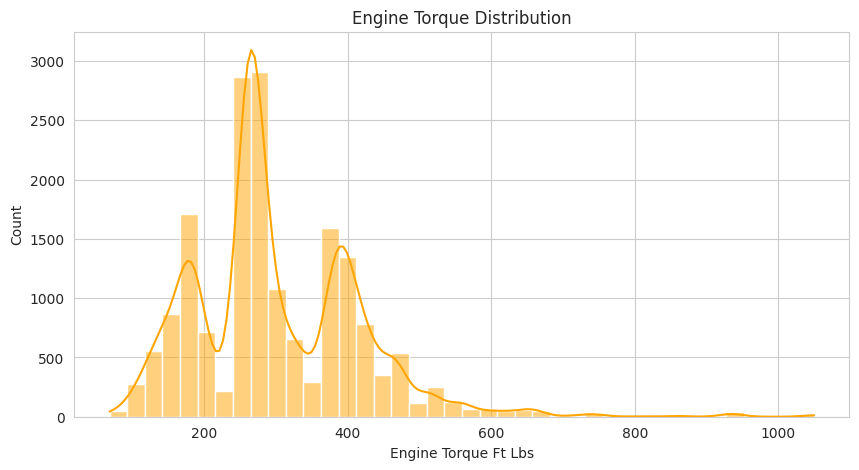

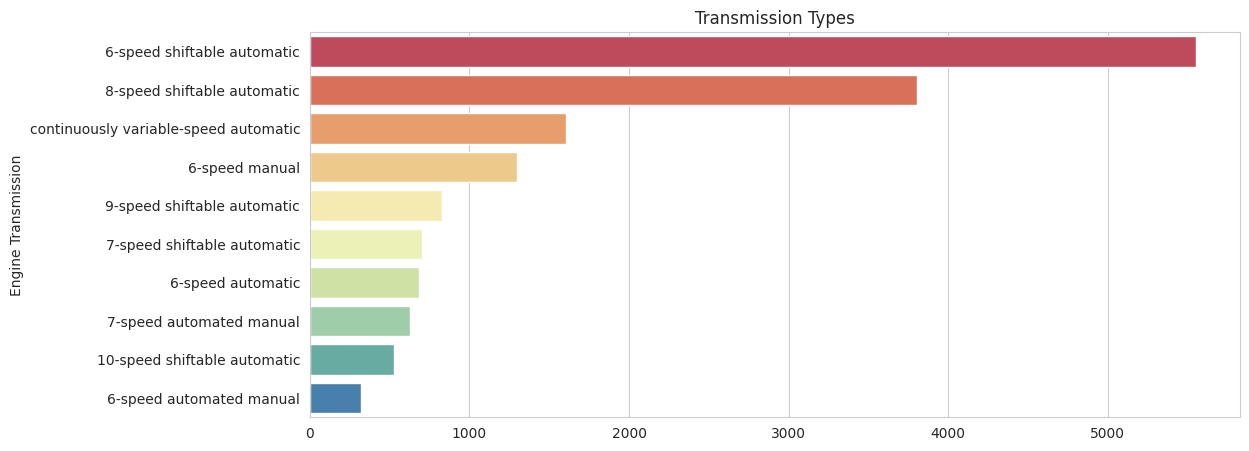

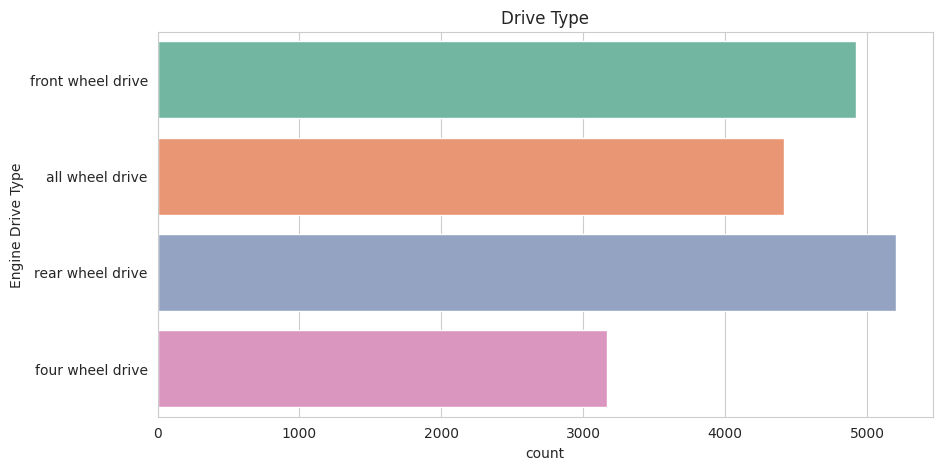

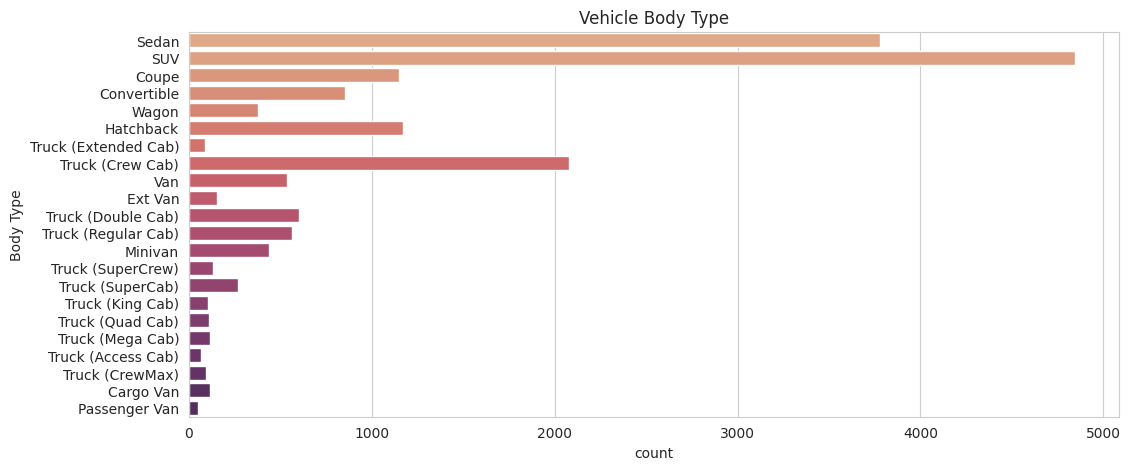

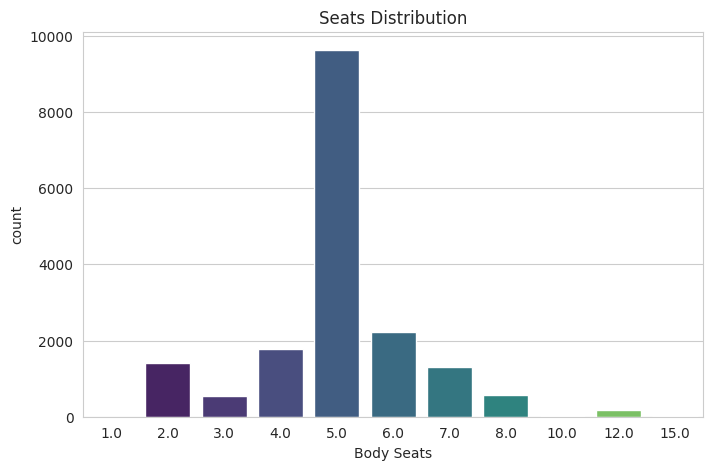

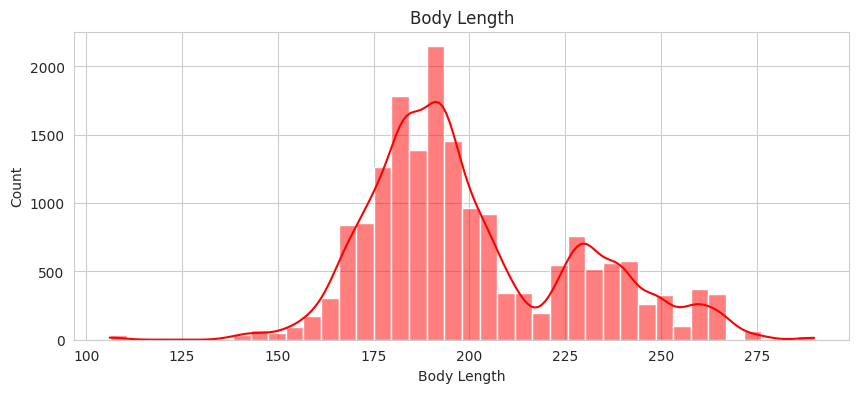

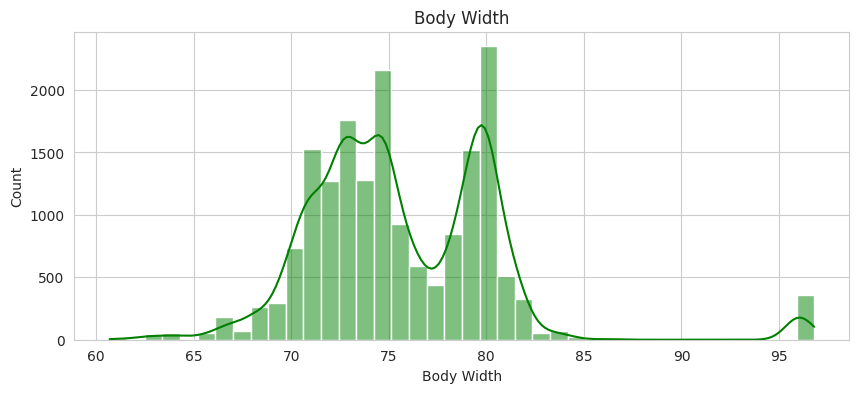

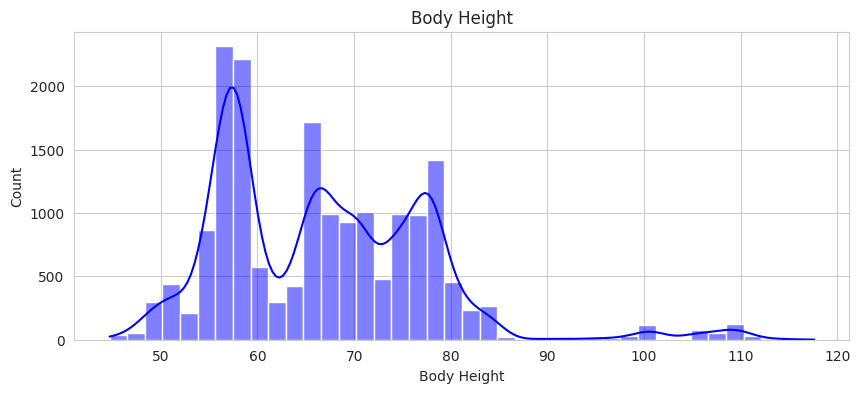

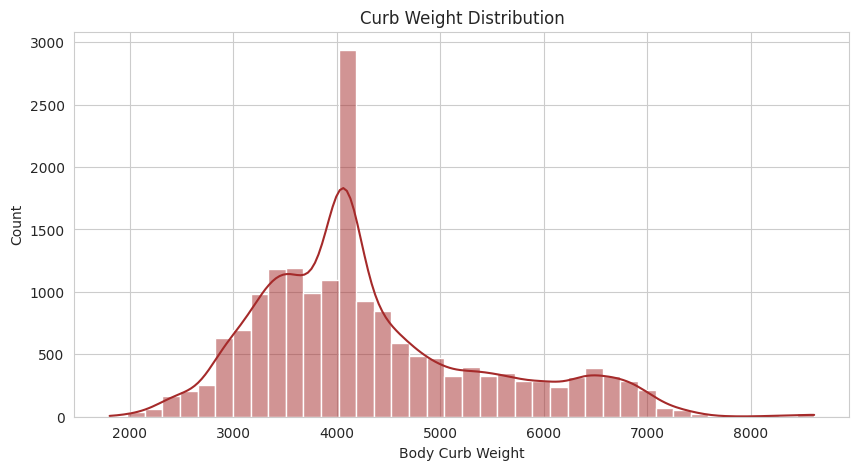

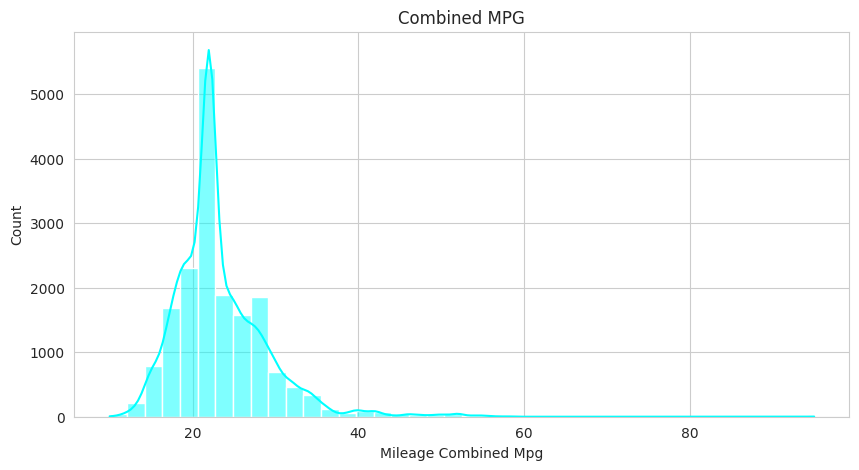

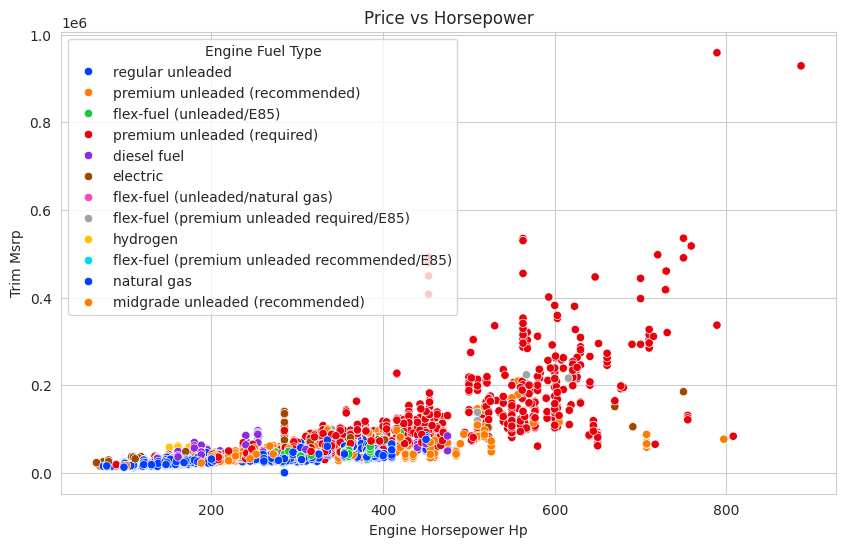

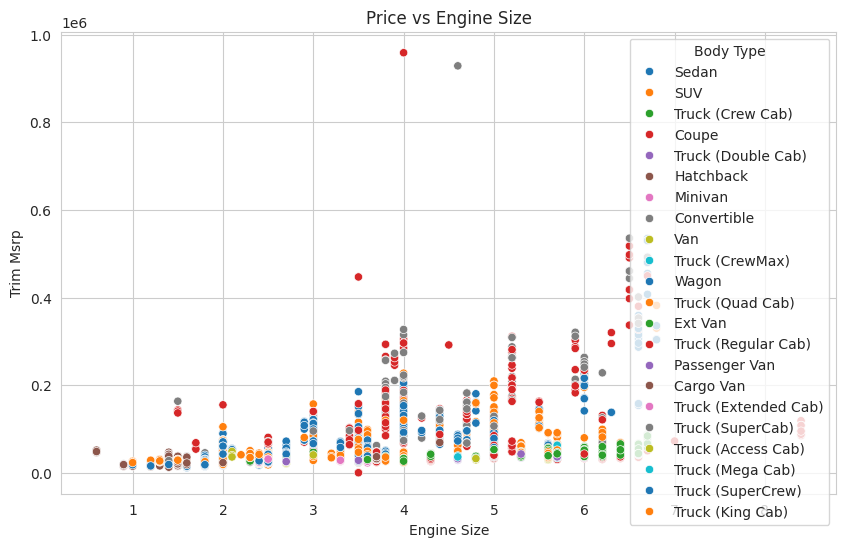

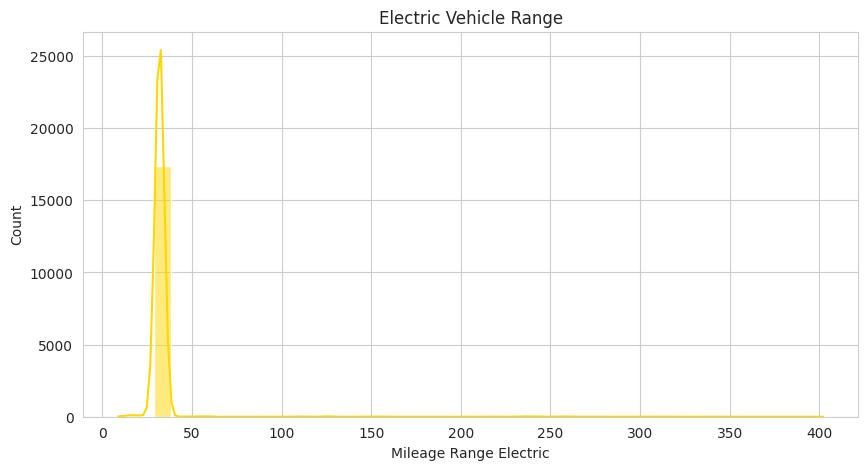

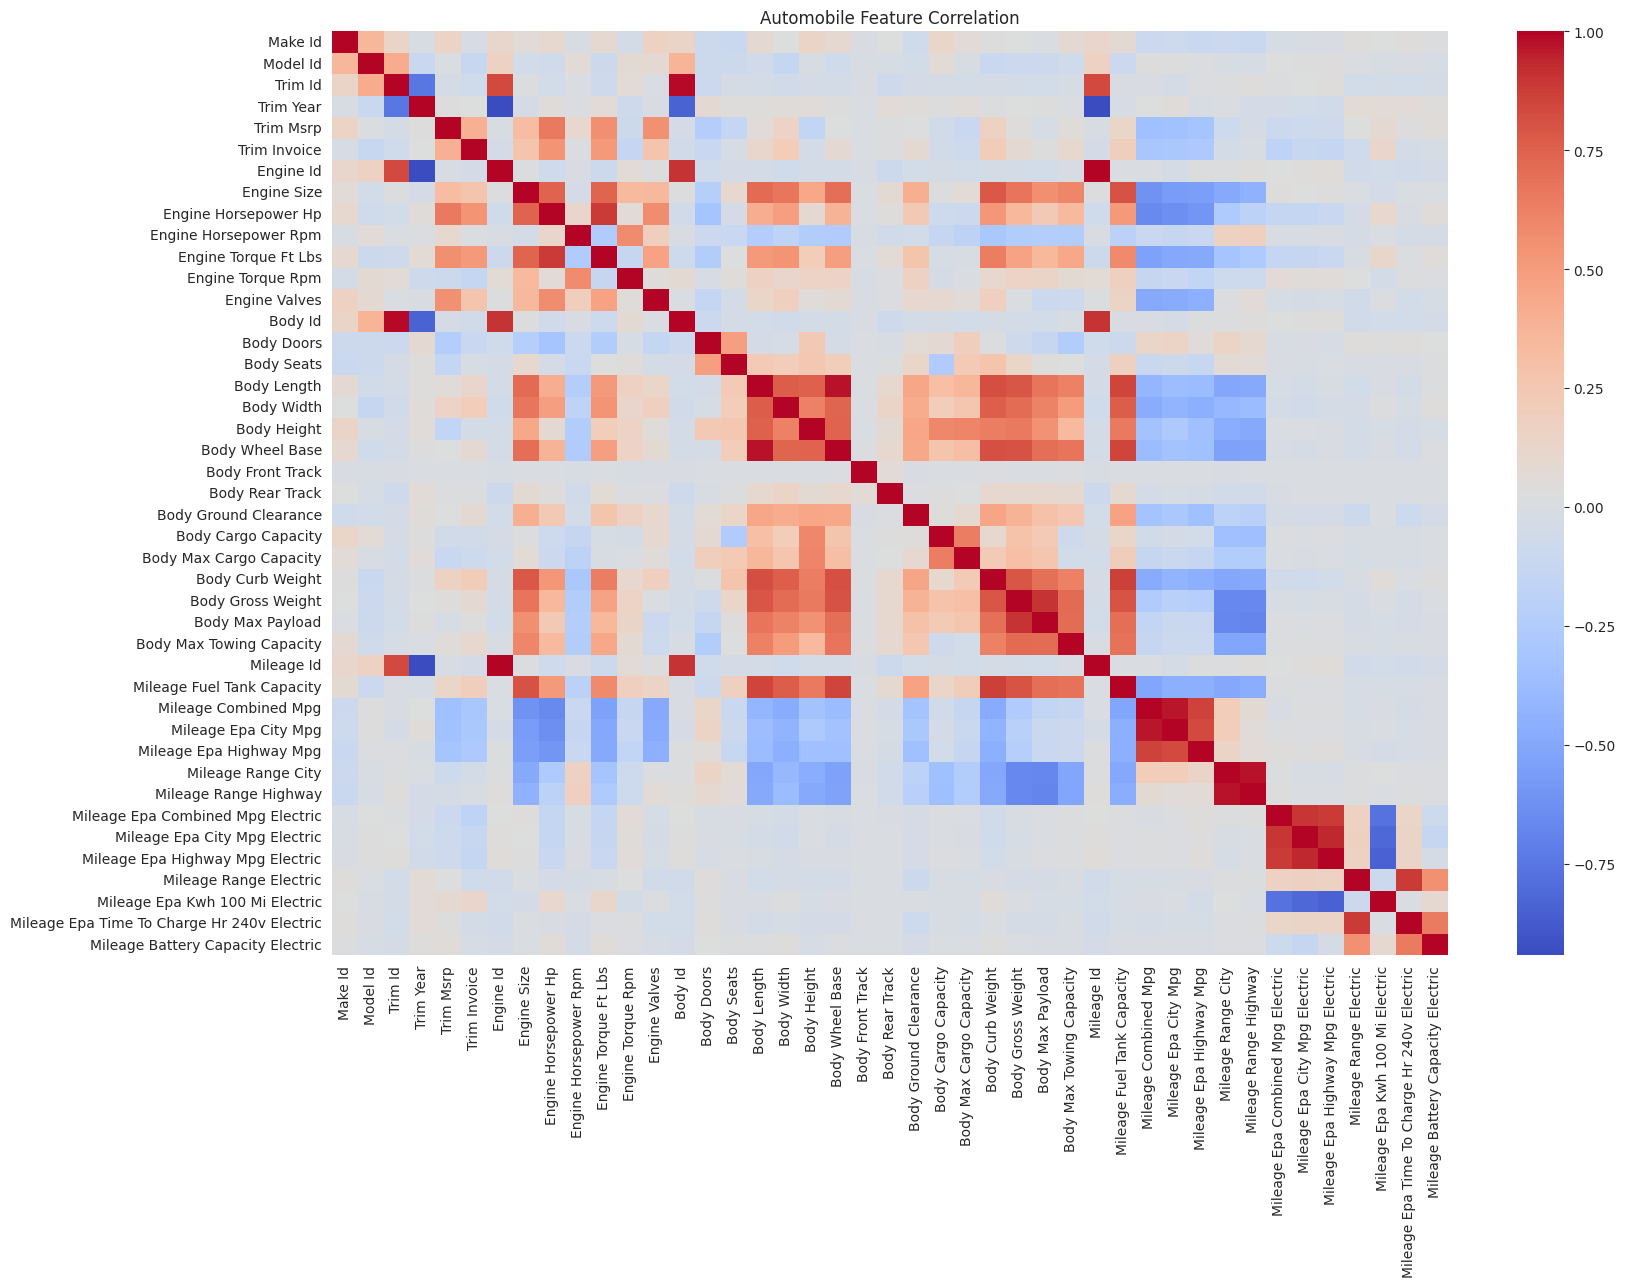

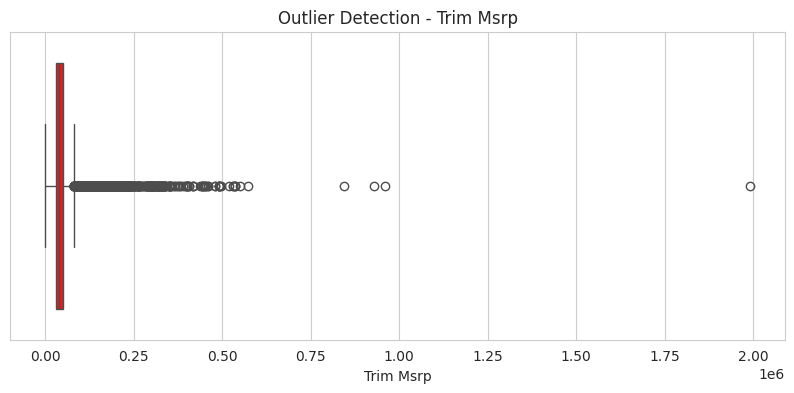

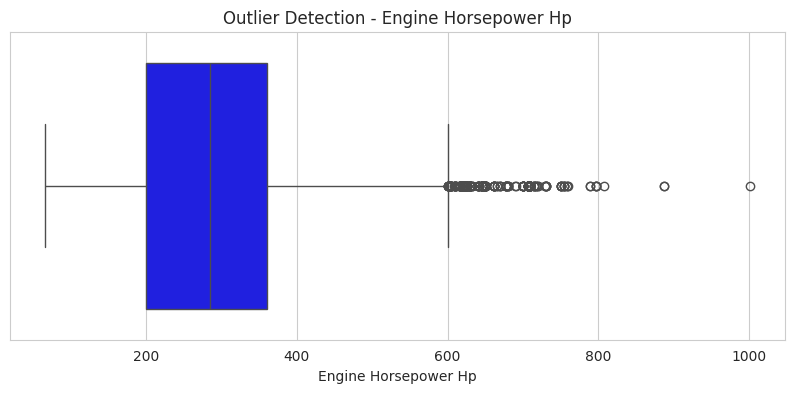

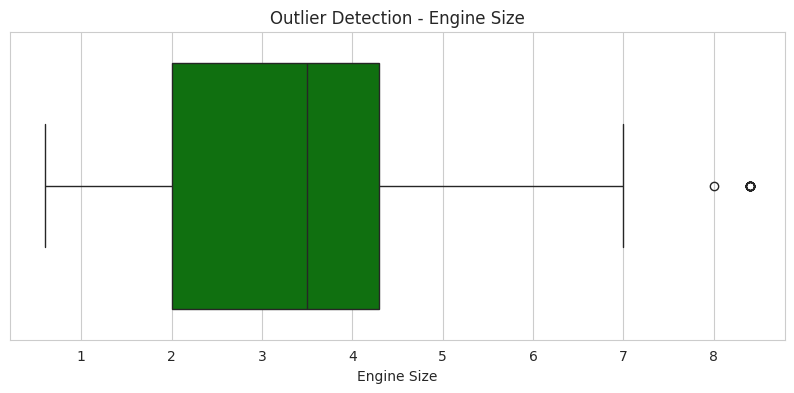

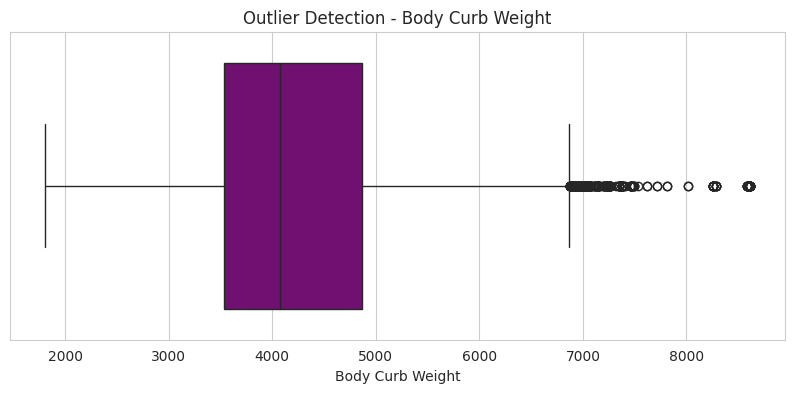

Automobile Visualization Completed Successfully


In [12]:
sns.set_style("whitegrid")

# ============================================================
# 1. TOP CAR MAKES
# ============================================================


make=df["Make Name"].value_counts().head(20)



plt.figure(figsize=(12,6))


sns.barplot(

x=make.values,

y=make.index,

hue=make.index,

palette="viridis",

legend=False

)



plt.title(
"Top Car Manufacturers"
)



plt.show()










# ============================================================
# 2. TOP MODELS
# ============================================================


model=df["Model Name"].value_counts().head(20)



plt.figure(figsize=(12,6))


sns.barplot(

x=model.values,

y=model.index,

hue=model.index,

palette="magma",

legend=False

)


plt.title(
"Popular Car Models"
)


plt.show()










# ============================================================
# 3. TRIM YEAR DISTRIBUTION
# ============================================================


plt.figure(figsize=(12,5))


sns.histplot(

df["Trim Year"],

bins=30,

kde=True,

color="blue"

)



plt.title(
"Vehicle Year Distribution"
)


plt.show()










# ============================================================
# 4. MSRP PRICE DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Trim Msrp"],

bins=50,

kde=True,

color="green"

)


plt.title(
"Vehicle MSRP Price Distribution"
)


plt.show()











# ============================================================
# 5. FUEL TYPE
# ============================================================


plt.figure(figsize=(12,5))


sns.countplot(

data=df,

y="Engine Fuel Type",

hue="Engine Fuel Type",

palette="coolwarm",

legend=False

)



plt.title(
"Fuel Type Distribution"
)


plt.show()










# ============================================================
# 6. ENGINE TYPE
# ============================================================


engine=df["Engine Type"].value_counts().head(15)



plt.figure(figsize=(12,6))


sns.barplot(

x=engine.values,

y=engine.index,

hue=engine.index,

palette="rocket",

legend=False

)


plt.title(
"Engine Type Count"
)


plt.show()










# ============================================================
# 7. ENGINE SIZE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Engine Size"],

bins=40,

kde=True,

color="purple"

)


plt.title(
"Engine Size Distribution"
)


plt.show()









# ============================================================
# 8. HORSEPOWER
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Engine Horsepower Hp"],

bins=40,

kde=True,

color="red"

)



plt.title(
"Horsepower Distribution"
)


plt.show()










# ============================================================
# 9. TORQUE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Engine Torque Ft Lbs"],

bins=40,

kde=True,

color="orange"

)


plt.title(
"Engine Torque Distribution"
)


plt.show()











# ============================================================
# 10. TRANSMISSION TYPE
# ============================================================


trans=df["Engine Transmission"].value_counts().head(10)



plt.figure(figsize=(12,5))


sns.barplot(

x=trans.values,

y=trans.index,

hue=trans.index,

palette="Spectral",

legend=False

)



plt.title(
"Transmission Types"
)



plt.show()











# ============================================================
# 11. DRIVE TYPE
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(

data=df,

y="Engine Drive Type",

hue="Engine Drive Type",

palette="Set2",

legend=False

)



plt.title(
"Drive Type"
)


plt.show()











# ============================================================
# 12. BODY TYPE
# ============================================================


plt.figure(figsize=(12,5))


sns.countplot(

data=df,

y="Body Type",

hue="Body Type",

palette="flare",

legend=False

)



plt.title(
"Vehicle Body Type"
)



plt.show()










# ============================================================
# 13. SEATS
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

data=df,

x="Body Seats",

hue="Body Seats",

palette="viridis",

legend=False

)


plt.title(
"Seats Distribution"
)


plt.show()











# ============================================================
# 14. BODY DIMENSIONS
# ============================================================


dimensions=[

"Body Length",

"Body Width",

"Body Height"

]


colors=[

"red",

"green",

"blue"

]



for col,color in zip(dimensions,colors):


    plt.figure(figsize=(10,4))


    sns.histplot(

    df[col],

    bins=40,

    kde=True,

    color=color

    )


    plt.title(
    col
    )


    plt.show()










# ============================================================
# 15. WEIGHT ANALYSIS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Body Curb Weight"],

bins=40,

kde=True,

color="brown"

)


plt.title(
"Curb Weight Distribution"
)


plt.show()











# ============================================================
# 16. MPG ANALYSIS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Mileage Combined Mpg"],

bins=40,

kde=True,

color="cyan"

)


plt.title(
"Combined MPG"
)


plt.show()











# ============================================================
# 17. PRICE VS HORSEPOWER
# ============================================================


sample=df.sample(

n=min(10000,len(df)),

random_state=42

)



plt.figure(figsize=(10,6))


sns.scatterplot(

data=sample,

x="Engine Horsepower Hp",

y="Trim Msrp",

hue="Engine Fuel Type",

palette="bright"

)



plt.title(
"Price vs Horsepower"
)



plt.show()











# ============================================================
# 18. PRICE VS ENGINE SIZE
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=sample,

x="Engine Size",

y="Trim Msrp",

hue="Body Type",

palette="tab10"

)



plt.title(
"Price vs Engine Size"
)


plt.show()










# ============================================================
# 19. ELECTRIC RANGE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Mileage Range Electric"],

bins=40,

kde=True,

color="gold"

)



plt.title(
"Electric Vehicle Range"
)


plt.show()










# ============================================================
# 20. CORRELATION HEATMAP
# ============================================================


numeric=df.select_dtypes(
include=np.number
)



plt.figure(figsize=(18,12))


sns.heatmap(

numeric.corr(),

cmap="coolwarm"

)



plt.title(
"Automobile Feature Correlation"
)


plt.show()











# ============================================================
# 21. OUTLIER DETECTION
# ============================================================


features=[

"Trim Msrp",

"Engine Horsepower Hp",

"Engine Size",

"Body Curb Weight"

]


colors=[

"red",

"blue",

"green",

"purple"

]




for f,c in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

    x=df[f],

    color=c

    )



    plt.title(
    f"Outlier Detection - {f}"
    )



    plt.show()








print(
"Automobile Visualization Completed Successfully"
)

## Features Engineering


Linear Regression
R2 Accuracy: 0.8939
MAE: 2172.11
RMSE: 14853.89

Decision Tree
R2 Accuracy: 0.9237
MAE: 2240.05
RMSE: 12601.82

Random Forest
R2 Accuracy: 0.916
MAE: 2203.08
RMSE: 13220.88

Gradient Boosting
R2 Accuracy: 0.8737
MAE: 6323.47
RMSE: 16207.1


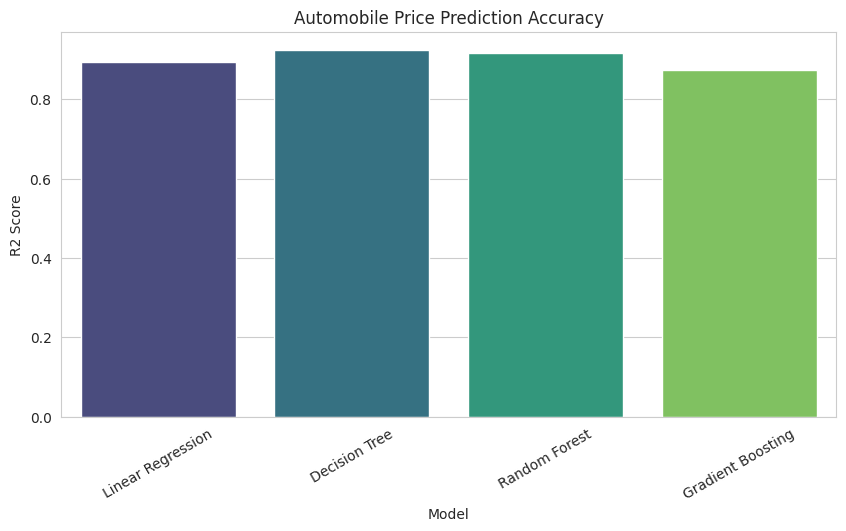

BEST MODEL: Decision Tree


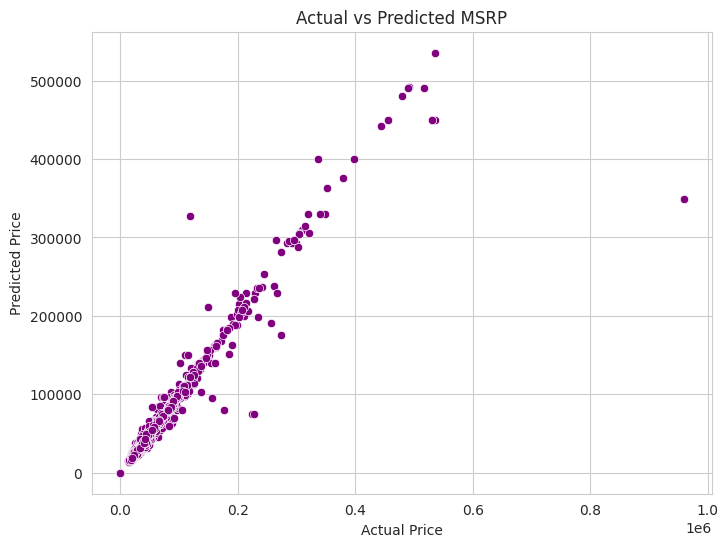

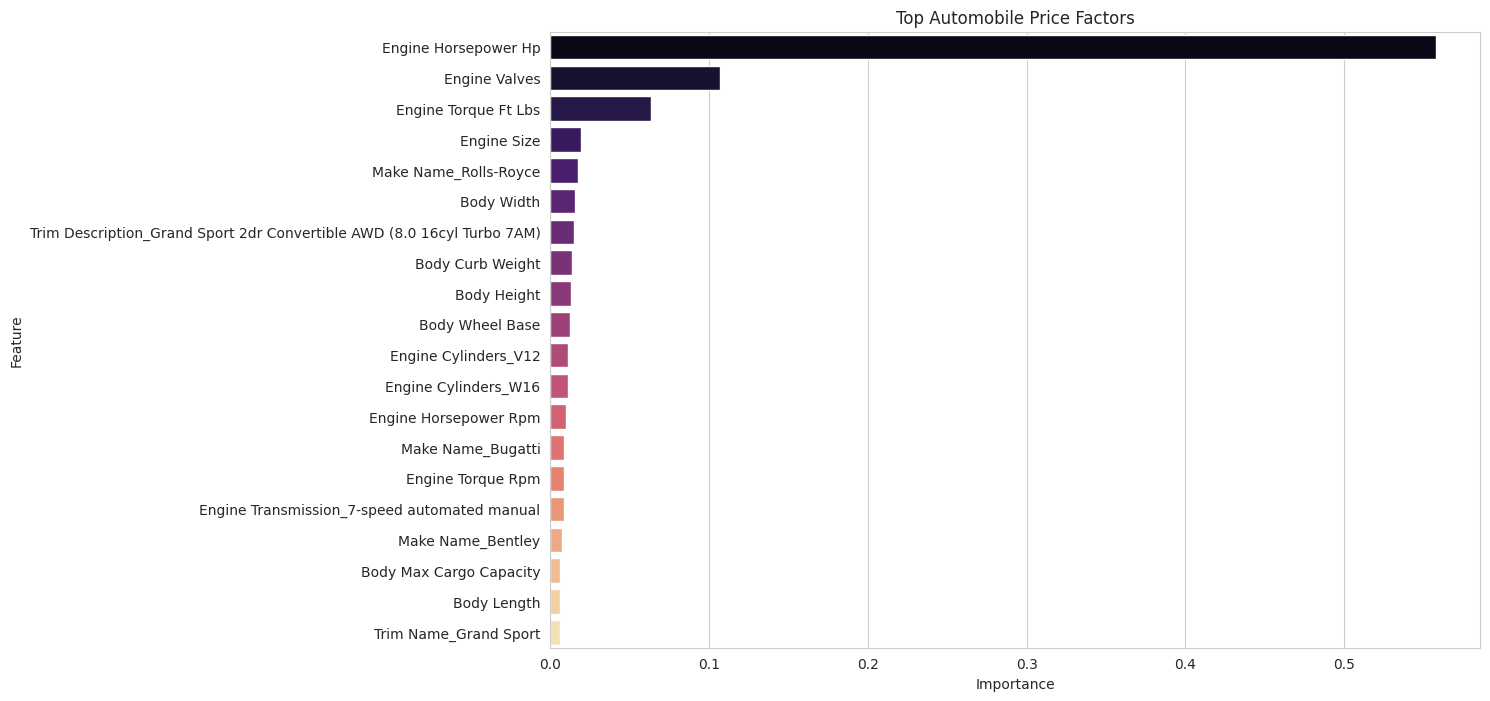


FINAL RESULT
Linear Regression : 0.8939
Decision Tree : 0.9237
Random Forest : 0.916
Gradient Boosting : 0.8737
BEST MODEL: Decision Tree
BEST ACCURACY: 0.9237


In [13]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)


from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)






# ============================================================
# DATE FEATURE ENGINEERING
# ============================================================


date_cols=[

"Trim Created",

"Trim Modified"

]


for col in date_cols:

    if col in df.columns:

        df[col]=pd.to_datetime(
            df[col],
            errors="coerce"
        )


        df[col+"_Year"]=df[col].dt.year

        df[col+"_Month"]=df[col].dt.month










# ============================================================
# TARGET
# ============================================================


target="Trim Msrp"



X=df.drop(

    target,

    axis=1

)



y=df[target]









# ============================================================
# REMOVE DATA LEAKAGE
# ============================================================


drop_cols=[


"Trim Invoice",   # directly related to price

"Trim Created",

"Trim Modified",


# IDs no predictive meaning

"Make Id",

"Model Id",

"Trim Id",

"Engine Id",

"Body Id",

"Mileage Id"


]




X=X.drop(

columns=drop_cols,

errors="ignore"

)









# ============================================================
# TRAIN TEST SPLIT FIRST
# ============================================================


X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)









# ============================================================
# COLUMN TYPES
# ============================================================


numeric_cols=X_train.select_dtypes(
    include=np.number
).columns



categorical_cols=X_train.select_dtypes(
    include="object"
).columns









# ============================================================
# NUMERIC PIPELINE
# ============================================================


numeric_pipeline=Pipeline(

steps=[


(

"imputer",

SimpleImputer(
strategy="median"
)

),



(

"scaler",

StandardScaler()

)


]

)









# ============================================================
# CATEGORICAL PIPELINE
# ============================================================


categorical_pipeline=Pipeline(

steps=[


(

"imputer",

SimpleImputer(
strategy="most_frequent"
)

),



(

"encoder",

OneHotEncoder(
handle_unknown="ignore"
)

)


]

)










# ============================================================
# PREPROCESSING
# ============================================================


preprocessor=ColumnTransformer(

transformers=[


(

"num",

numeric_pipeline,

numeric_cols

),


(

"cat",

categorical_pipeline,

categorical_cols

)


]

)









# ============================================================
# ML ALGORITHMS
# ============================================================


models={



"Linear Regression":

LinearRegression(),




"Decision Tree":

DecisionTreeRegressor(
random_state=42
),





"Random Forest":

RandomForestRegressor(

n_estimators=200,

random_state=42,

n_jobs=-1

),





"Gradient Boosting":

GradientBoostingRegressor(

random_state=42

)


}









results={}

trained={}










# ============================================================
# TRAINING
# ============================================================


for name,model in models.items():


    print("\n====================")
    print(name)
    print("====================")




    pipe=Pipeline(

    steps=[



    (

    "preprocess",

    preprocessor

    ),




    (

    "model",

    model

    )



    ]

    )








    pipe.fit(

        X_train,

        y_train

    )








    pred=pipe.predict(

        X_test

    )







    r2=r2_score(

        y_test,

        pred

    )





    mae=mean_absolute_error(

        y_test,

        pred

    )





    rmse=np.sqrt(

        mean_squared_error(

        y_test,

        pred

        )

    )







    results[name]=r2

    trained[name]=pipe








    print(

    "R2 Accuracy:",

    round(r2,4)

    )


    print(

    "MAE:",

    round(mae,2)

    )


    print(

    "RMSE:",

    round(rmse,2)

    )










# ============================================================
# ACCURACY COMPARISON
# ============================================================


accuracy=pd.DataFrame({

"Model":list(results.keys()),

"R2 Score":list(results.values())

})





plt.figure(figsize=(10,5))


sns.barplot(

data=accuracy,

x="Model",

y="R2 Score",

hue="Model",

palette="viridis",

legend=False

)



plt.title(
"Automobile Price Prediction Accuracy"
)


plt.xticks(rotation=30)

plt.show()










# ============================================================
# BEST MODEL
# ============================================================


best_name=max(

results,

key=results.get

)



best_model=trained[
best_name
]




print(

"BEST MODEL:",

best_name

)










# ============================================================
# ACTUAL VS PREDICTED PRICE
# ============================================================


prediction=best_model.predict(

X_test

)





plt.figure(figsize=(8,6))


sns.scatterplot(

x=y_test,

y=prediction,

color="purple"

)



plt.xlabel(
"Actual Price"
)



plt.ylabel(
"Predicted Price"
)



plt.title(
"Actual vs Predicted MSRP"
)


plt.show()










# ============================================================
# FEATURE IMPORTANCE
# ============================================================


rf=trained[
"Random Forest"
]





feature_names=(

list(numeric_cols)

+

list(

rf.named_steps["preprocess"]

.named_transformers_["cat"]

.named_steps["encoder"]

.get_feature_names_out(

categorical_cols

)

)

)






importance=pd.DataFrame({


"Feature":feature_names,


"Importance":

rf.named_steps["model"]

.feature_importances_

})






importance=importance.sort_values(

"Importance",

ascending=False

)






plt.figure(figsize=(12,8))


sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)



plt.title(
"Top Automobile Price Factors"
)


plt.show()









# ============================================================
# FINAL RESULT
# ============================================================


print("\nFINAL RESULT")

print("===================")


for model,score in results.items():

    print(
        model,
        ":",
        round(score,4)
    )



print("===================")



print(

"BEST MODEL:",

best_name

)



print(

"BEST ACCURACY:",

round(max(results.values()),4)

)

## Thanks..............Please Upvote